In [1]:
import os, sys
os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser  # type: ignore
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from copy import deepcopy


In [2]:
figure_path = 'Gardner_data_test/figures'

In [3]:
sys.path.append('.')
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from toroidal_coordinates.dreimac_toroidal import compute_toroidal_coords_dreimac
from toroidal_coordinates.compute_coord import visualize_tor_coords_x_traj, interp_arr
from utils import get_spikes, fit_para, toroidal_alignment, plot_barcode, get_ratemaps
from persistence_homology import computeDistanceMatrix
from angle_fns import circmean
from toroidal_coordinates.epsilon import compute_epsilon
from Gardner_data_test.Gardner_lifting_test import gaussian_smooth_toroidal, interpolate_2d_along_axis_0
from constants import *

In [4]:
def Gardner_coord_temp(interp10: bool = False):
    folder = 'Toroidal_topology_grid_cell_data/'

    rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
    sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                        bSmooth = True, bSpeed = True, folder = folder )
    if interp10:
        sspikes = interpolate_2d_along_axis_0(sspikes, sspikes.shape[0]*10) # makes sspikes 10 times longer

    # coords, times = compute_toroidal_coords_dreimac(d, standard_range=False, distance_matrix=True)
    coords, times, _, _ = Gardner_coord(sspikes)

    compute_epsilon(coords)
    plt.show()

    xx = interp_arr(xx, coords.shape[0])
    yy = interp_arr(yy, coords.shape[0])
    times = np.arange(xx.shape[0])
    visualize_tor_coords_x_traj(xx, yy, coords, times)

    # coordsbox, times_box, centcosall, centsinall = Gardner_coord(sspikes, xx, yy)
    print(coords.shape, times.shape, xx.shape, yy.shape)
    plt.show()
    # import pdb; pdb.set_trace()
    lifted_coords = toroidal_lifting_distance(coords)

    smooth_factor = 10
    if interp10:
        smooth_factor = 100

    original_coords = np.concatenate([xx[:, None], yy[:, None]], axis=1)

    return lifted_coords, original_coords

In [5]:
def get_coords():
    folder = 'Toroidal_topology_grid_cell_data/'

    rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
    sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                        bSmooth = True, bSpeed = True, folder = folder )

    # coords, times = compute_toroidal_coords_dreimac(d, standard_range=False, distance_matrix=True)
    coords, times, _, _ = Gardner_coord(sspikes)
    
    return coords

/home/yyao01/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


3.9793359622685216
(126728, 2)
(126728, 2) (126728,) (126728,) (126728,)


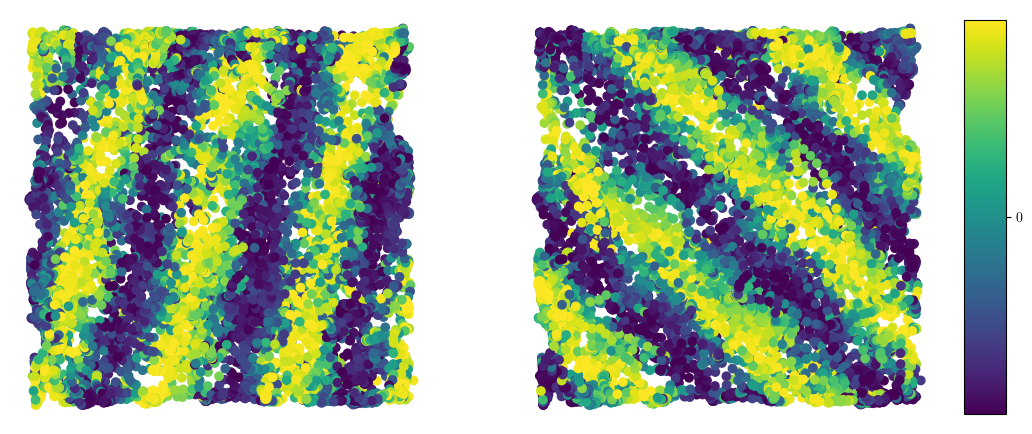

3.9793359622685216


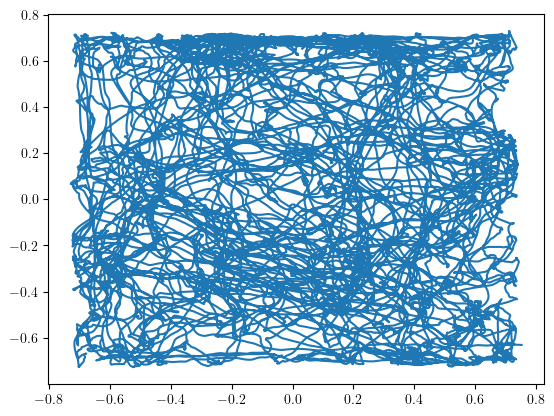

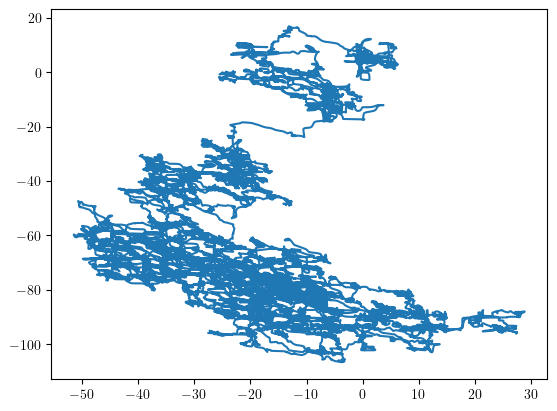

In [6]:
lifted, original = Gardner_coord_temp(interp10=False)
plt.figure()
plt.plot(original[:, 0], original[:, 1])
plt.figure()
plt.plot(lifted[:, 0], lifted[:, 1])
plt.savefig(os.path.join(GARDNER_TEST_FIG_PATH, 'lifted_traj.png'), dpi=500)

/home/yyao01/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


0.7874778262212914
(1267280, 2)
(1267280, 2) (1267280,) (1267280,) (1267280,)


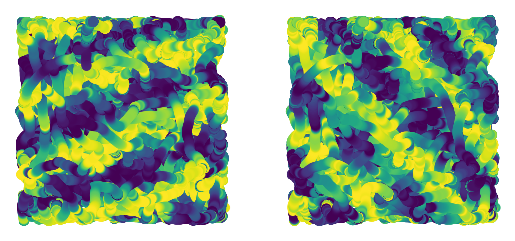

0.7874778262212914


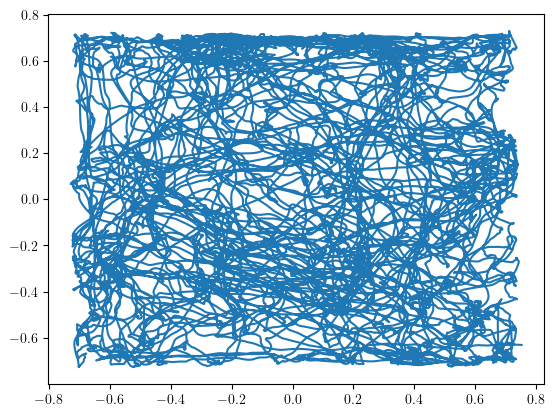

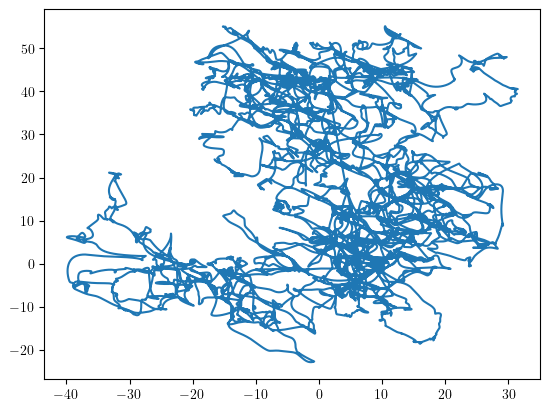

In [7]:
lifted10, original10 = Gardner_coord_temp(interp10=True)
plt.figure()
plt.plot(original10[:, 0], original10[:, 1])
plt.figure()
plt.plot(lifted10[:, 0], lifted10[:, 1])

In [ ]:
coords = get_coords()

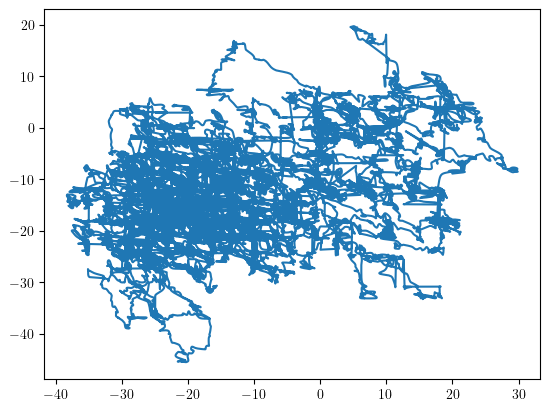

In [19]:
_pathx = np.unwrap(coords[:, 0], discont=5.8)
_pathy = np.unwrap(coords[:, 1], discont=5.8)
plt.figure()
plt.plot(_pathx, _pathy)

## Comparing the lifted paths with the original paths by segments

### Uninterpolated

In [7]:
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from affine_transform.score_mismatch import score_mismatch
np.random.seed(0)
len_seg = 2000
len_seg10 = len_seg*10
colors = plt.cm.viridis(np.linspace(0, 1, len_seg))
colors10 = plt.cm.viridis(np.linspace(0, 1, len_seg10))

64


/tmp/ipykernel_1173687/378593291.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 3))


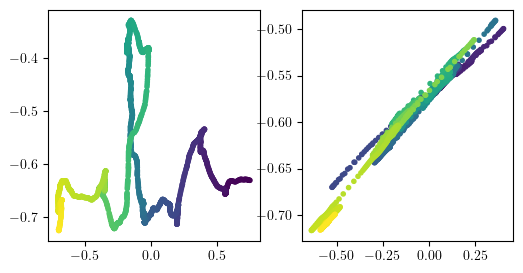

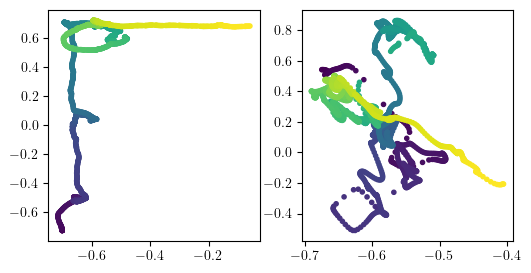

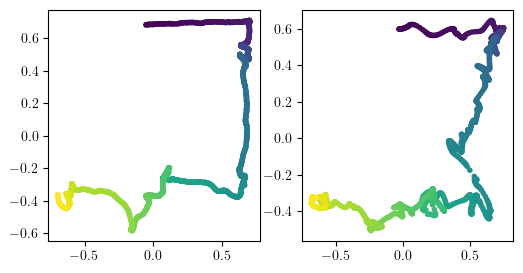

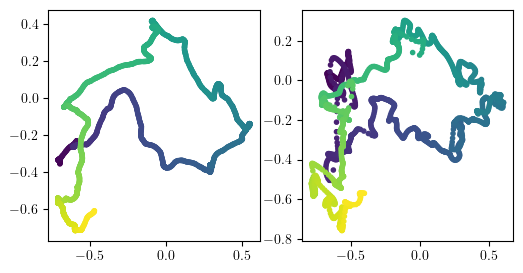

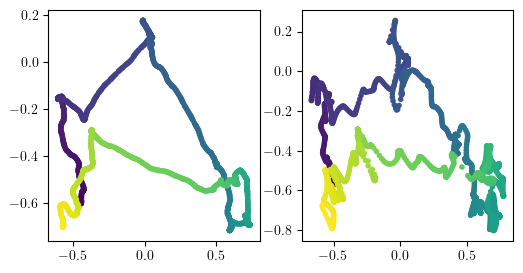

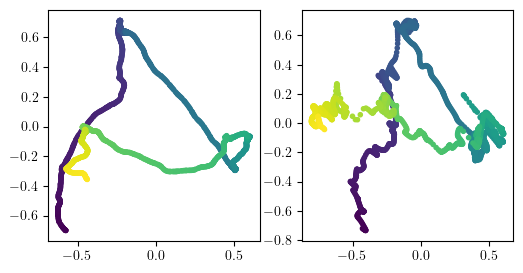

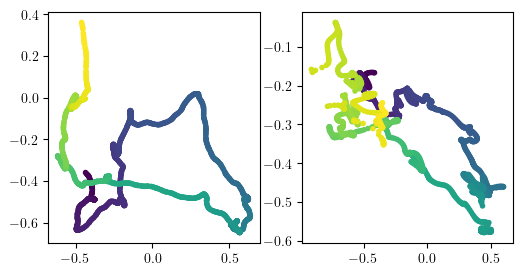

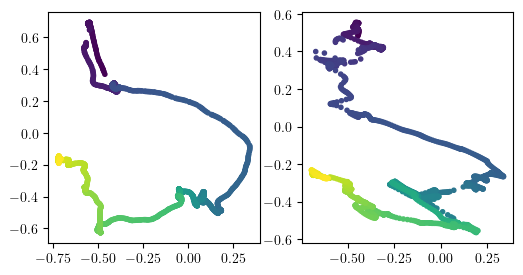

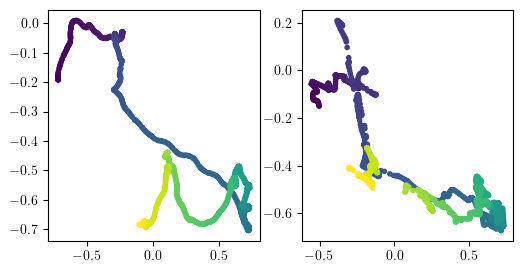

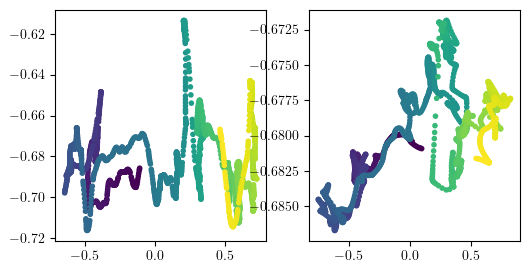

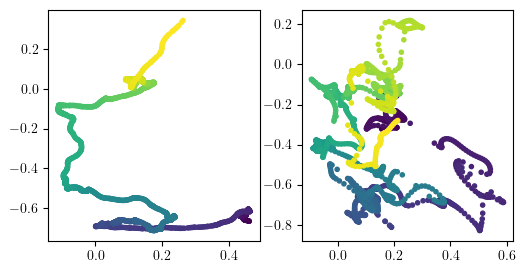

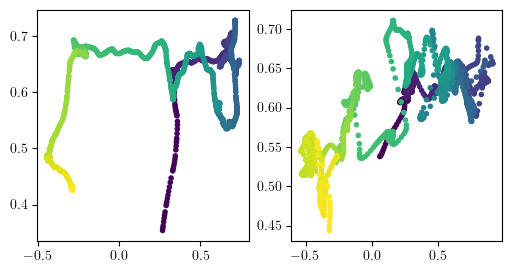

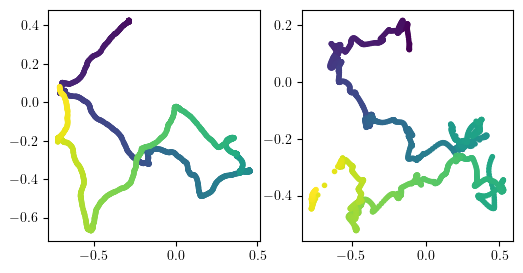

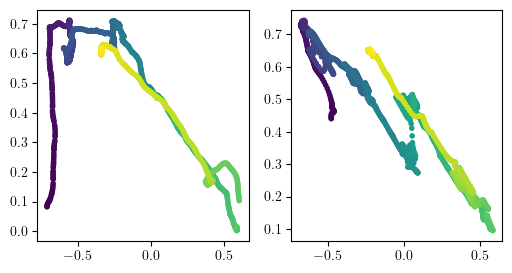

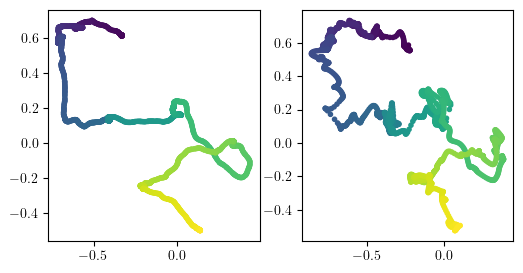

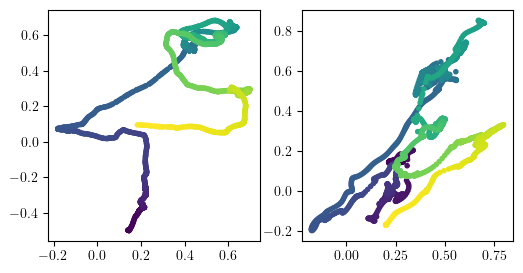

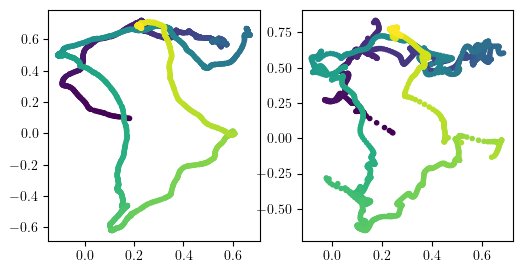

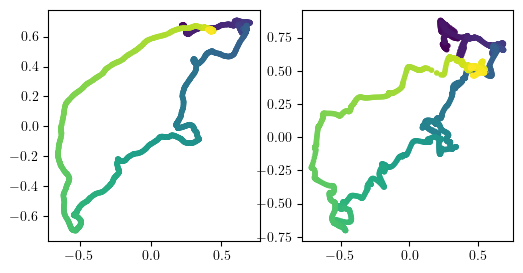

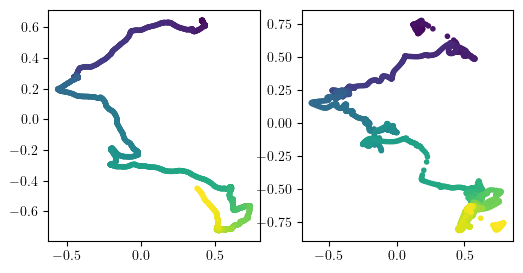

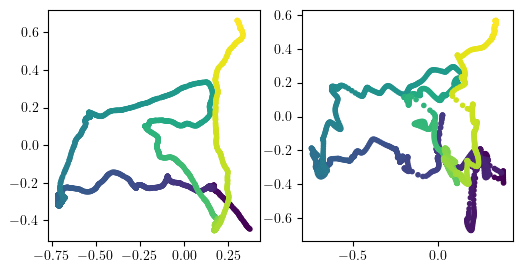

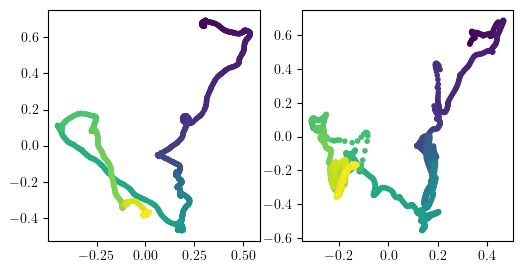

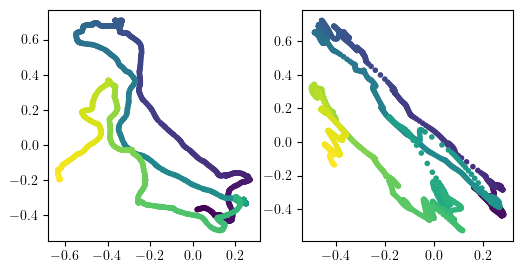

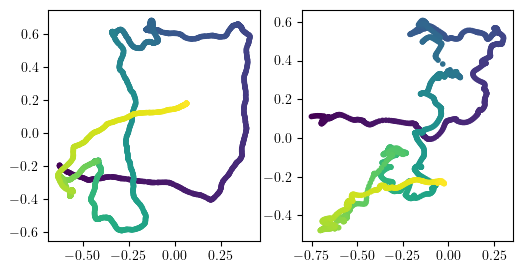

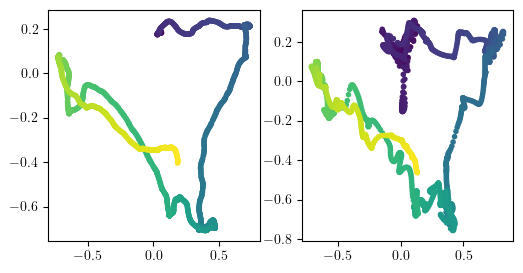

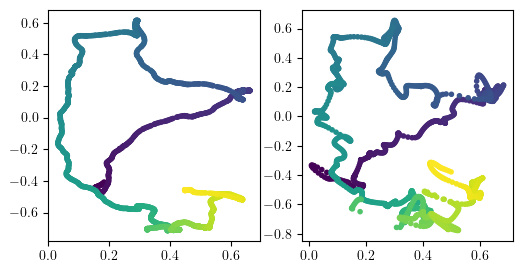

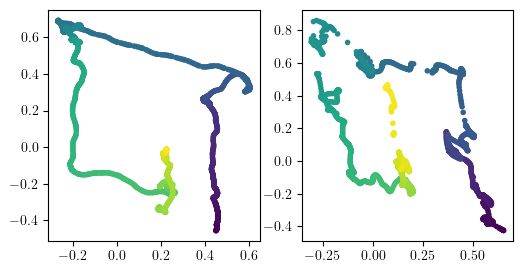

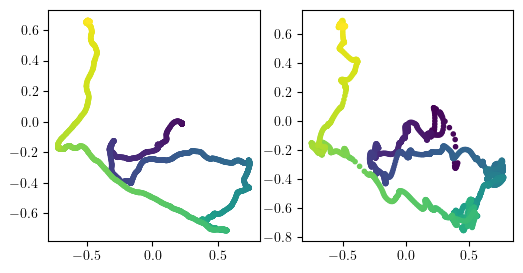

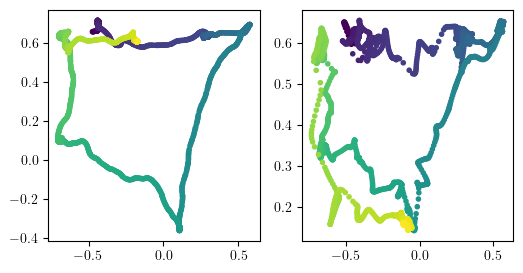

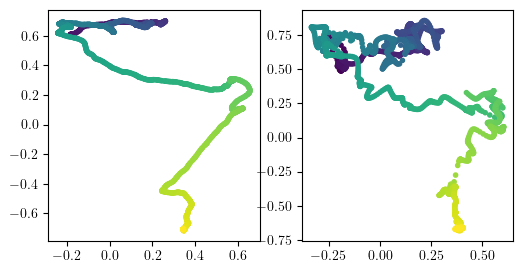

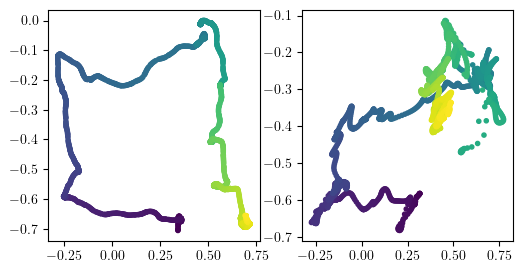

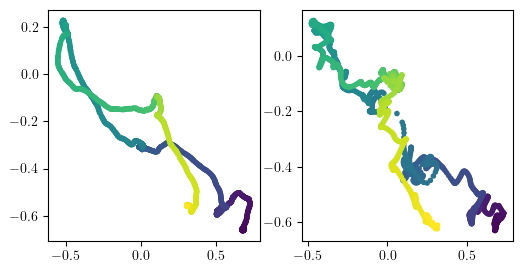

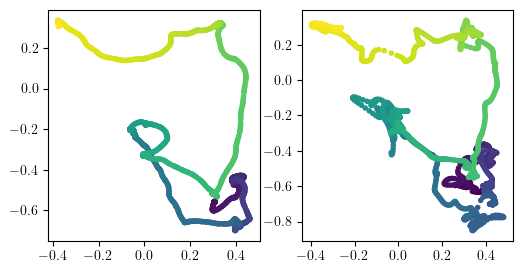

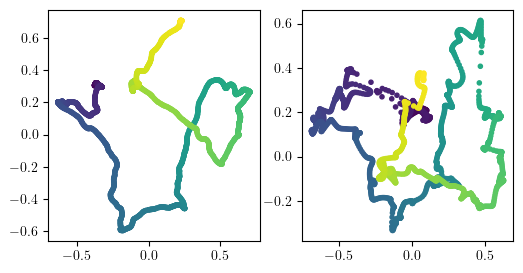

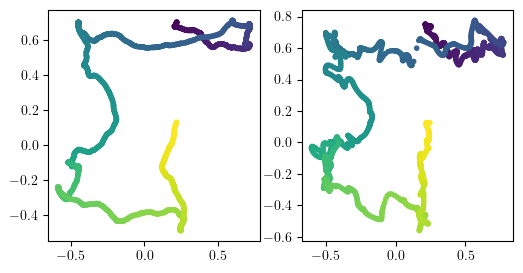

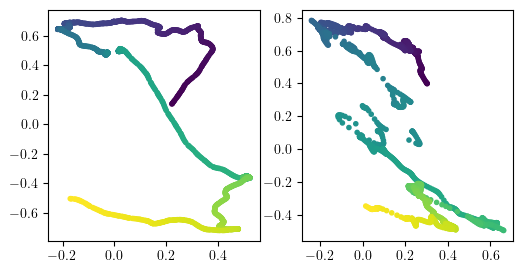

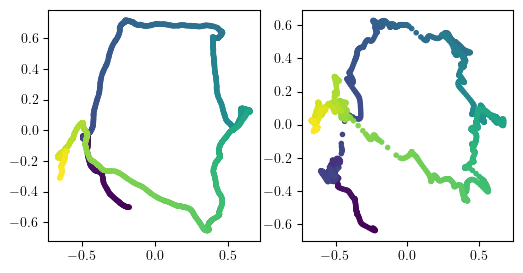

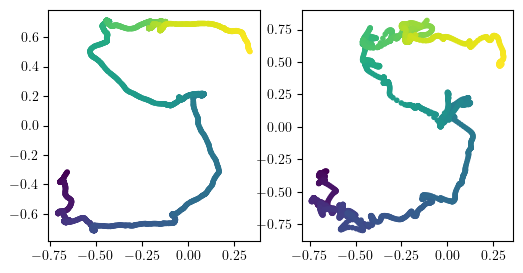

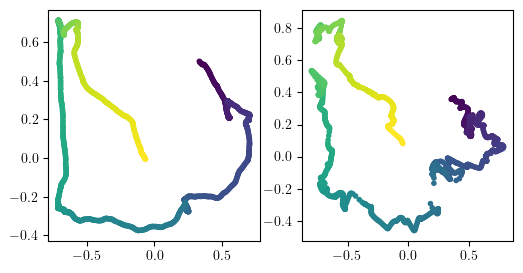

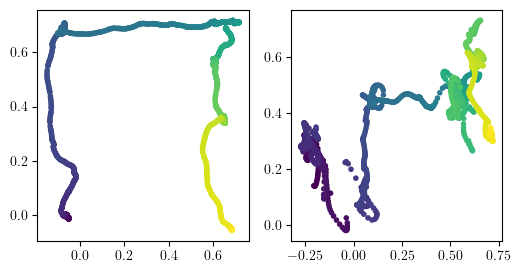

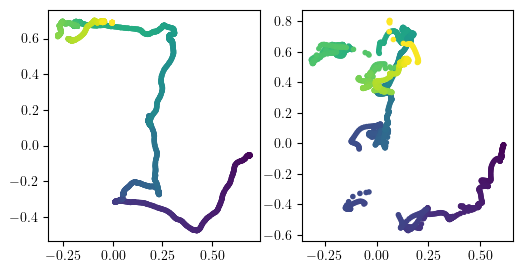

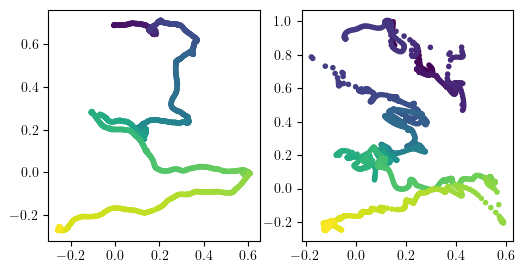

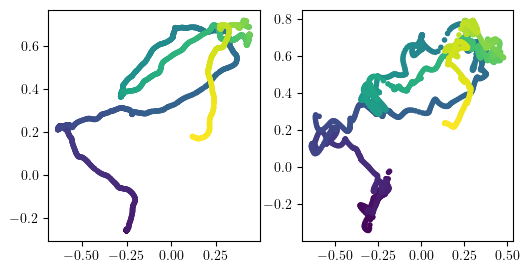

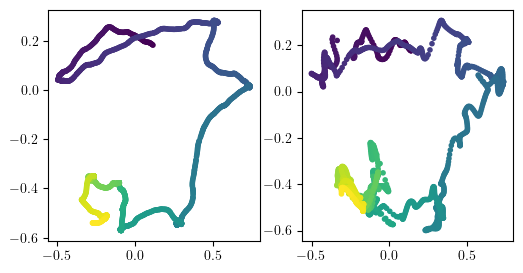

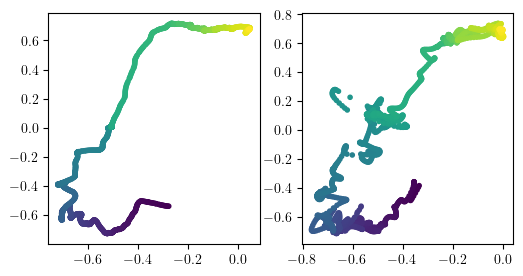

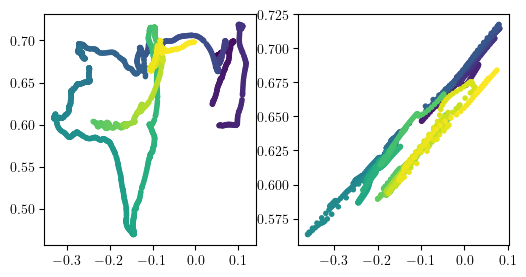

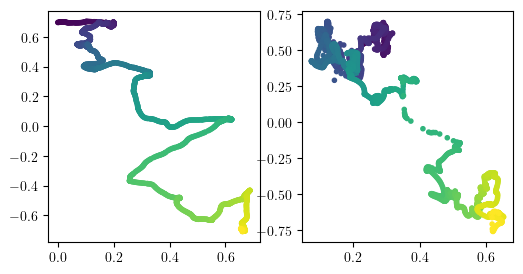

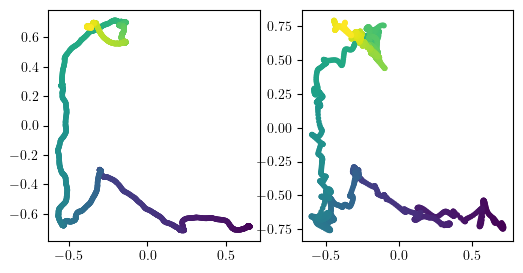

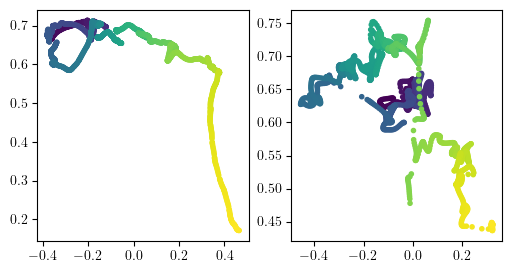

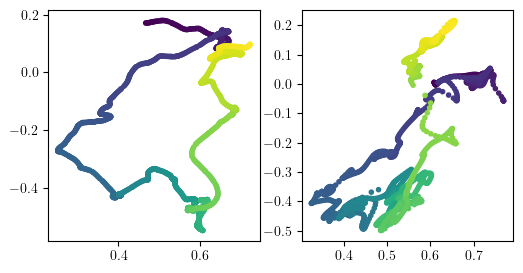

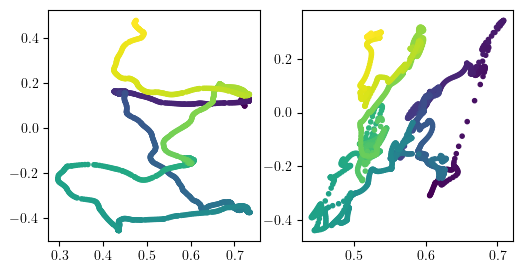

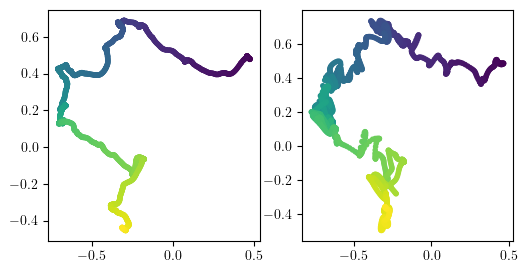

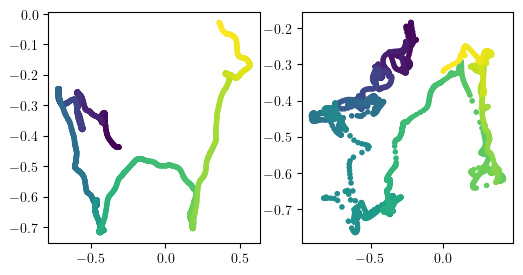

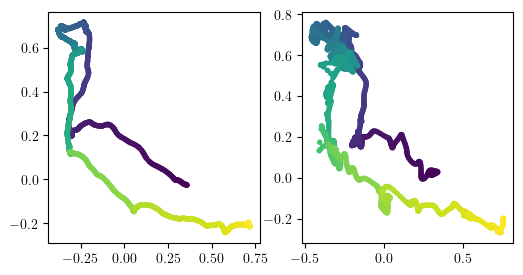

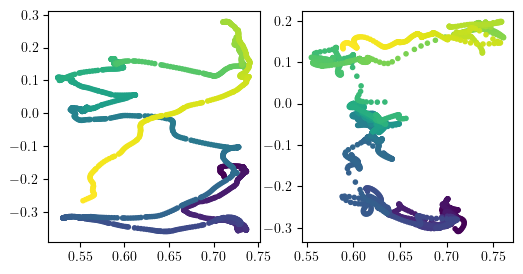

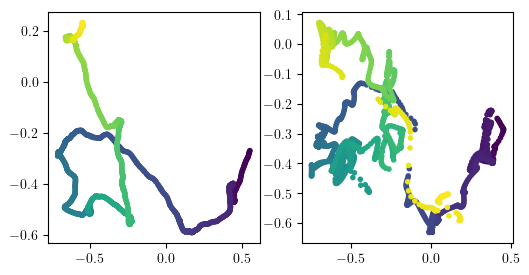

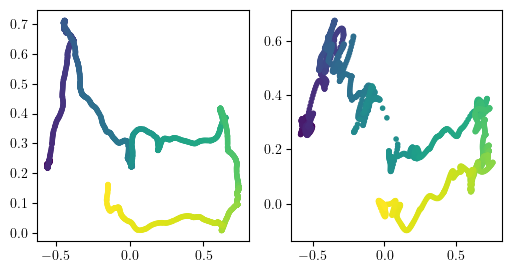

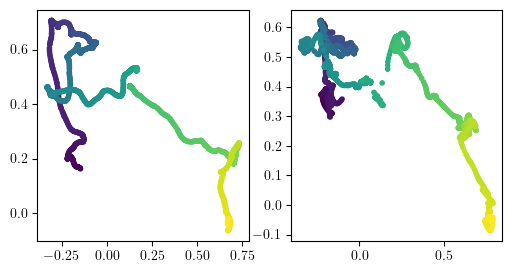

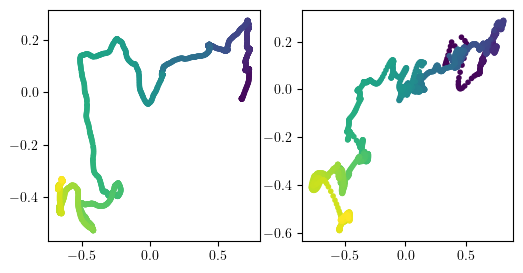

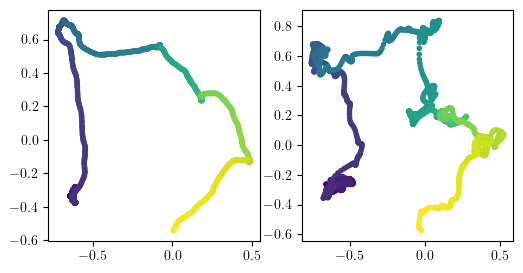

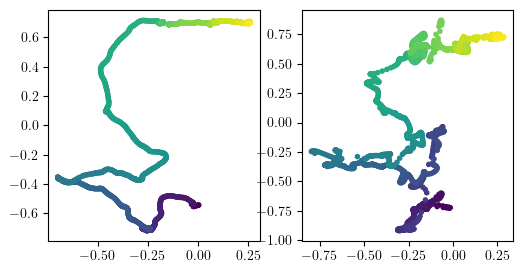

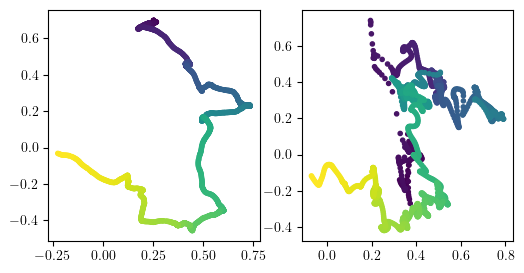

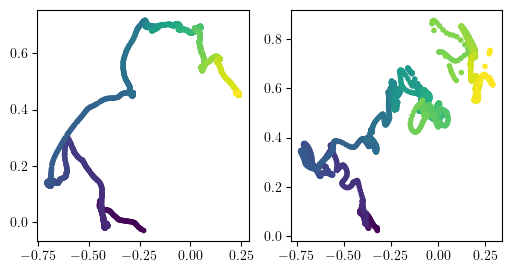

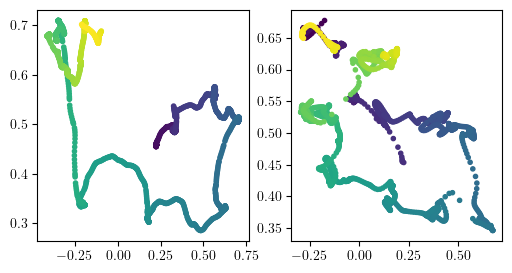

In [8]:
num_seg = lifted.shape[0]//len_seg+1
print(num_seg)
uninterp_mismatch = []
for i in range(num_seg):
    original_seg = original[i*len_seg:(i+1)*len_seg]
    lifted_seg = lifted[i*len_seg:(i+1)*len_seg]
    transform_mat = get_transform_mat(lifted_seg, original_seg)
    recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)
    uninterp_mismatch.append(score_mismatch(recovered_lifted, original_seg))
    if i < num_seg - 1:
        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors)
        plt.subplot(1, 2, 2)
        plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
        plt.savefig(os.path.join(GARDNER_TEST_FIG_PATH, 'lifted_segments', f'seg_{i}.png'), dpi=300)

### Interpolated

64


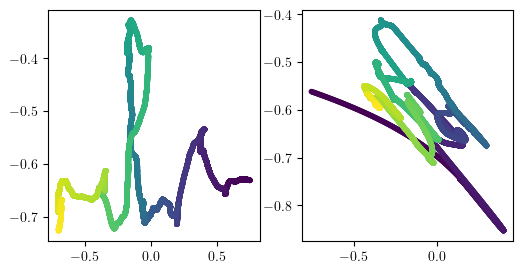

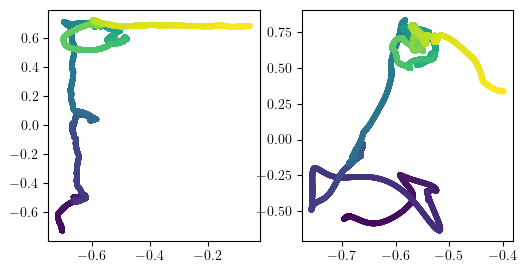

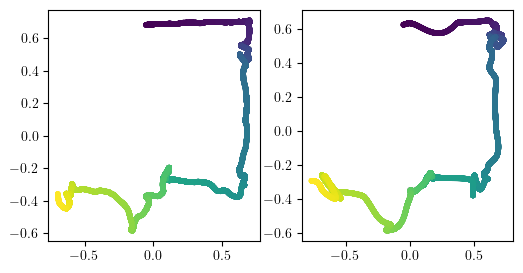

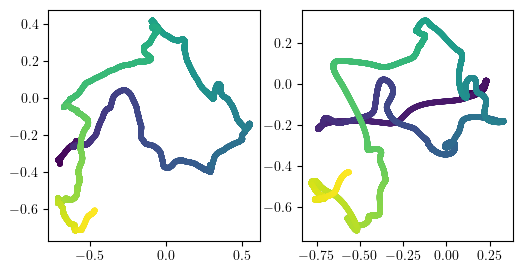

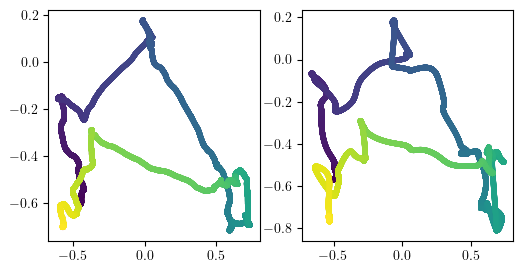

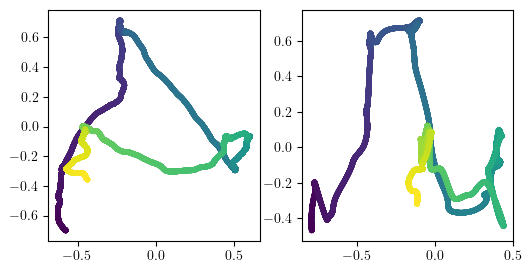

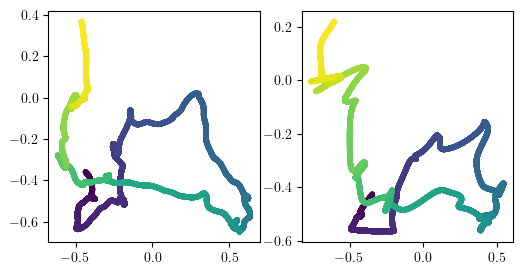

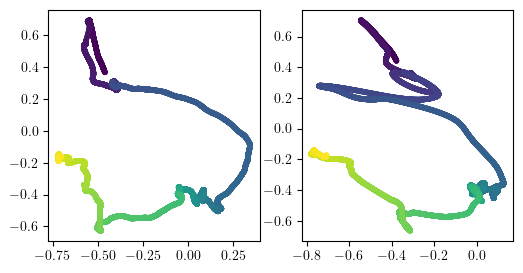

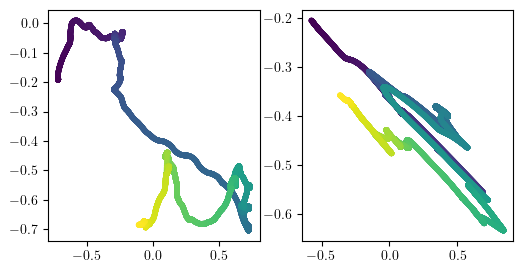

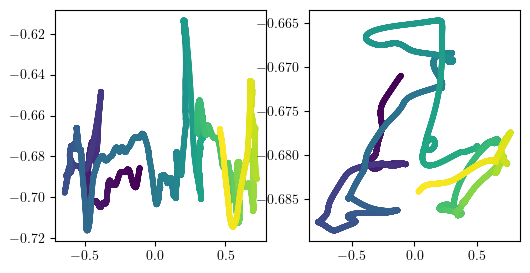

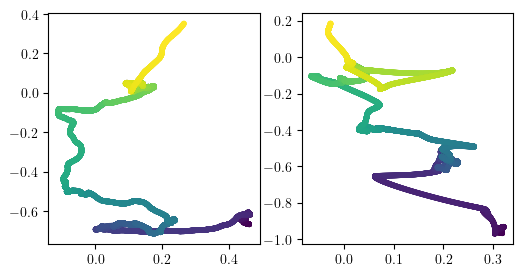

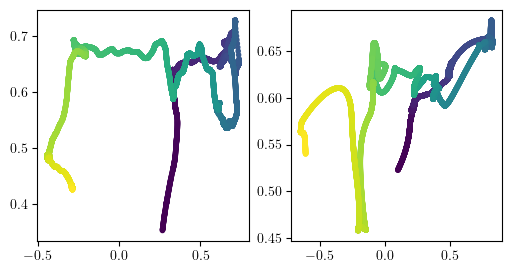

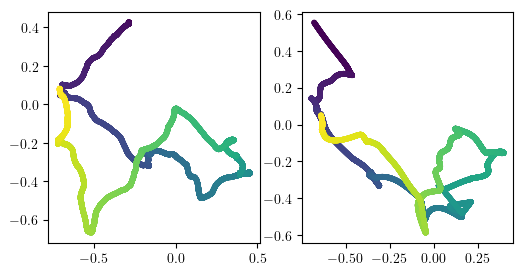

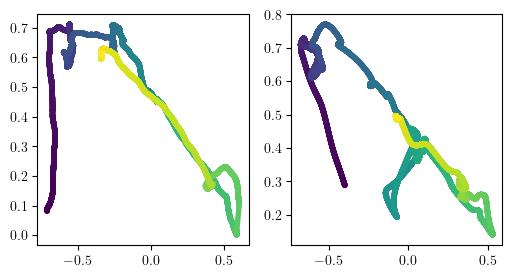

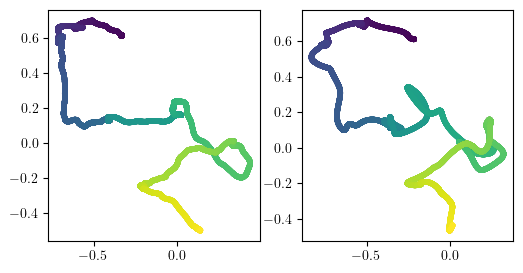

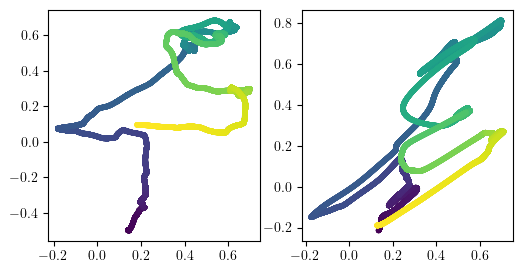

In [10]:
num_seg = lifted10.shape[0]//len_seg10+1
print(num_seg)
interp_mismatch = []
for i in range(num_seg):
    original_seg = original10[i*len_seg10:(i+1)*len_seg10]
    lifted_seg = lifted10[i*len_seg10:(i+1)*len_seg10]
    transform_mat = get_transform_mat(lifted_seg, original_seg)
    recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)
    interp_mismatch.append(score_mismatch(recovered_lifted, original_seg))
    if i <= 15:
        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors10)
        plt.subplot(1, 2, 2)
        plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors10)

0.1080093473855239


(array([10.,  8.,  4.,  6.,  5.,  2.,  1.,  3.,  7.,  6.,  3.,  2.,  2.,
         3.,  0.,  1.,  0.,  0.,  0.,  1.]),
 array([0.03577881, 0.04788931, 0.0599998 , 0.0721103 , 0.08422079,
        0.09633129, 0.10844178, 0.12055228, 0.13266277, 0.14477327,
        0.15688376, 0.16899426, 0.18110475, 0.19321525, 0.20532575,
        0.21743624, 0.22954674, 0.24165723, 0.25376773, 0.26587822,
        0.27798872]),
 <BarContainer object of 20 artists>)

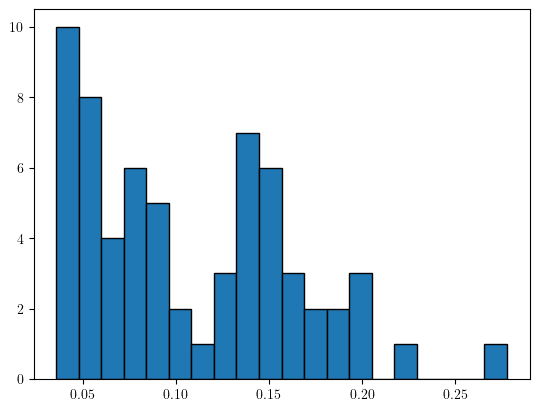

In [9]:
print(np.mean(uninterp_mismatch))
plt.hist(uninterp_mismatch, bins=20, edgecolor='black')

In [10]:
print(np.mean(interp_mismatch))
plt.hist(interp_mismatch, bins=20, edgecolor='black')

NameError: name 'interp_mismatch' is not defined

0.23698698855996891


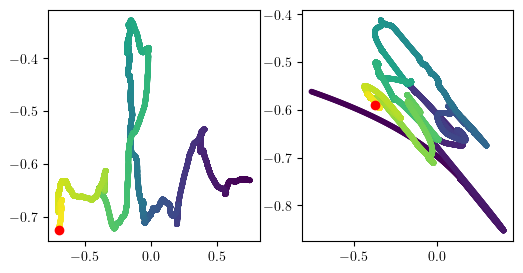

In [ ]:

from scipy.spatial.distance import cdist # type: ignore
i=0
original_seg = original10[i*len_seg10:(i+1)*len_seg10]
lifted_seg = lifted10[i*len_seg10:(i+1)*len_seg10]
transform_mat = get_transform_mat(lifted_seg, original_seg)
recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)
print(score_mismatch(recovered_lifted, original_seg))
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors10)
plt.scatter(original_seg[-1, 0], original_seg[-1, 1], marker='o', color='red')
plt.subplot(1, 2, 2)
plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors10)
plt.scatter(recovered_lifted[-1, 0], recovered_lifted[-1, 1], marker='o', color='red')

In [11]:
def euclidean_distance():
    return np.sqrt(np.sum((x-y)**2))

In [12]:
print(cdist(recovered_lifted, original_seg, metric='euclidean').diagonal())

NameError: name 'cdist' is not defined

In [13]:
# pair-wise comparison to generate a null space mismatch
all_original_segs = np.array([original[i*len_seg:(i+1)*len_seg] for i in range(num_seg-1)])

In [14]:
mismatch_matrix = np.zeros((num_seg-1, num_seg-1))
for i in range(num_seg-1):
    for j in range(i+1, num_seg-1):
        original_seg1 = all_original_segs[i]
        original_seg2 = all_original_segs[j]
        affine_mat = get_transform_mat(original_seg2, original_seg1)
        transformed_seg2 = apply_transform_mat(original_seg2, affine_mat)
        mismatch_matrix[i, j] = score_mismatch(original_seg1, transformed_seg2)
np.save(os.path.join(GARDNER_TEST_FIG_PATH, 'null_mismatch_matrix.npy'), mismatch_matrix)

In [13]:
print(mismatch_matrix)

[[0.         0.15847713 0.1592093  ... 0.20186536 0.18785657 0.23541925]
 [0.         0.         0.13683648 ... 0.24953647 0.17118154 0.30428817]
 [0.         0.         0.         ... 0.244853   0.20063222 0.32767888]
 ...
 [0.         0.         0.         ... 0.         0.20168852 0.23115127]
 [0.         0.         0.         ... 0.         0.         0.20411219]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [16]:
null_mismatch = mismatch_matrix.flatten()
null_mismatch = null_mismatch[null_mismatch > 0]
null_mismatch.mean(), null_mismatch.std()

(0.2876296135728233, 0.08909597473131127)

In [17]:
from scipy.stats import ttest_ind
ttest_ind(uninterp_mismatch, null_mismatch)

TtestResult(statistic=-14.930804859650241, pvalue=6.84918082916482e-48, df=2015.0)

0.20411219050091767


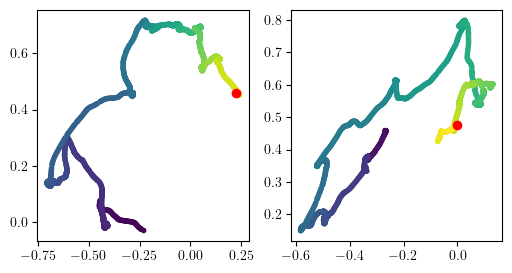

In [35]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.scatter(original_seg1[:, 0], original_seg1[:, 1], marker='.', color=colors)
plt.scatter(original_seg1[-1, 0], original_seg1[-1, 1], marker='o', color='red')
plt.subplot(1, 2, 2)
plt.scatter(transformed_seg2[:, 0], transformed_seg2[:, 1], marker='.', color=colors)
plt.scatter(transformed_seg2[-1, 0], transformed_seg2[-1, 1], marker='o', color='red')
print(score_mismatch(original_seg1, transformed_seg2))

(array([ 21.,  34.,  52.,  86., 127., 187., 189., 241., 229., 177., 176.,
        148., 103.,  77.,  34.,  33.,  19.,   9.,   8.,   3.]),
 array([0.0713336 , 0.09720799, 0.12308238, 0.14895677, 0.17483116,
        0.20070555, 0.22657994, 0.25245433, 0.27832872, 0.30420311,
        0.3300775 , 0.35595189, 0.38182628, 0.40770067, 0.43357506,
        0.45944945, 0.48532384, 0.51119823, 0.53707262, 0.56294701,
        0.5888214 ]),
 <BarContainer object of 20 artists>)

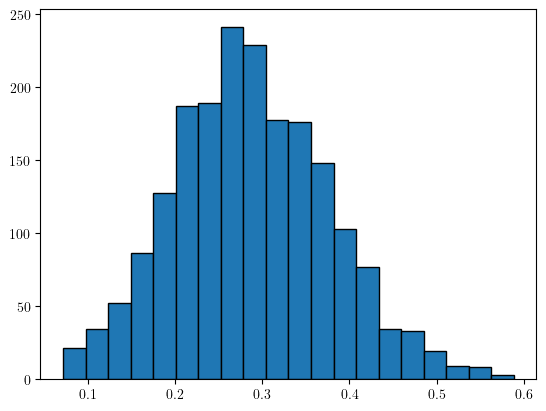

In [42]:
all_scores = mismatch_matrix.flatten()
all_scores = all_scores[all_scores != 0]
plt.hist(all_scores, bins=20, edgecolor='black')

In [57]:
import scipy.stats as stats
print(stats.ttest_ind(uninterp_mismatch, all_scores))
print(stats.ttest_ind(interp_mismatch, all_scores))
print(stats.ttest_rel(uninterp_mismatch, interp_mismatch))

TtestResult(statistic=-14.930804859650374, pvalue=6.849180829152498e-48, df=2015.0)
TtestResult(statistic=-11.808650208603032, pvalue=3.6559734878827247e-31, df=2015.0)
TtestResult(statistic=-3.2159864668496723, pvalue=0.0020528494353483483, df=63)
